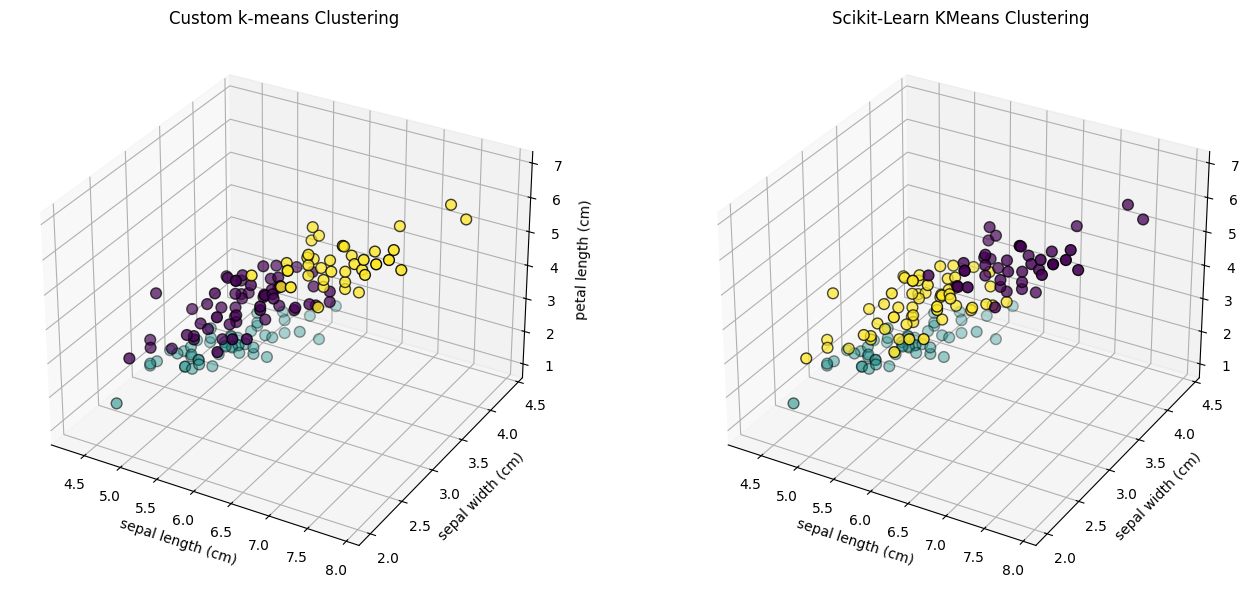

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans as SklearnKMeans

# K-MEANS ALGORITHM
class CustomKMeans:
    def __init__(self, k):
        self.k = k
        self.cluster_labels = None
        
    def fit(self, X):
        np.random.seed(42) # Added for reproducible centroids
        self.centroids = X[np.random.choice(X.shape[0], self.k, replace=False), :]
        self.cluster_labels = np.arange(self.k)        
        while True:
            distances = np.array([np.linalg.norm(X - centroid, axis=1) for centroid in self.centroids])
            self.clusters = np.argmin(distances, axis=0)
            new_centroids = np.array([X[self.clusters == i, :].mean(axis=0) for i in range(self.k)])
            # check convergence
            if np.array_equal(new_centroids, self.centroids):
                break
            else:
                self.centroids = new_centroids

    def predict(self, X):
        distances = np.array([np.linalg.norm(X - centroid, axis=1) for centroid in self.centroids])
        return self.cluster_labels[np.argmin(distances, axis=0)]


# DATA PREPARATION (THREE Features)

# Load Iris Dataset
data = load_iris()
# Select only the first THREE features: Sepal Length, Sepal Width, Petal Length
X = data['data'][:, :3] 
feature_names = data['feature_names'][:3]


# APPLY CUSTOM AND SKLEARN CLUSTERING

# Number of clusters set to 3 
k = 3

# Apply Custom k-means
custom_model = CustomKMeans(k=k)
custom_model.fit(X)
custom_labels = custom_model.predict(X)

# Apply Scikit-Learn k-means
sklearn_model = SklearnKMeans(n_clusters=k, random_state=42, n_init=10)
sklearn_labels = sklearn_model.fit_predict(X)


# ==========================================
# 4. 3D VISUALIZATION
# ==========================================
fig = plt.figure(figsize=(14, 6))

# Plot 1: Custom k-means
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=custom_labels, cmap='viridis', s=60, edgecolor='k')
ax1.set_title('Custom k-means Clustering')
ax1.set_xlabel(feature_names[0])
ax1.set_ylabel(feature_names[1])
ax1.set_zlabel(feature_names[2])

# Plot 2: Sklearn k-means
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(X[:, 0], X[:, 1], X[:, 2], c=sklearn_labels, cmap='viridis', s=60, edgecolor='k')
ax2.set_title('Scikit-Learn KMeans Clustering')
ax2.set_xlabel(feature_names[0])
ax2.set_ylabel(feature_names[1])
ax2.set_zlabel(feature_names[2])

plt.tight_layout()
plt.show()